# Data loading

In [54]:
print("Hello Jupyter")


Hello Jupyter


In [76]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)

numpy: 2.2.6
pandas: 2.3.1
matplotlib: 3.10.5
seaborn: 0.13.2


In [77]:

df = pd.read_csv("mesa_agent_results.csv")
df.head()


,day,hour,step,agent_id,agent_type,room,current_temp,comfort_level,using_ac,preferred_temp
0,NaN,NaN,0,student_0,student,West Zone,23.0,23.0,True,25.235675
1,NaN,NaN,0,student_1,student,West Zone,23.0,23.0,False,24.078777
2,NaN,NaN,0,student_2,student,West Zone,23.0,23.0,True,25.487461
3,NaN,NaN,0,student_3,student,East Zone,23.0,23.0,True,25.076618
4,NaN,NaN,0,student_4,student,West Zone,23.0,23.0,False,25.351459


In [78]:
df.isnull().sum()

day               25344
hour              25344
step                  0
agent_id              0
agent_type            0
room                  0
current_temp          0
comfort_level      3990
using_ac              0
preferred_temp        0
dtype: int64

In [79]:
df['comfort_level'] = df['comfort_level'].fillna(0)

In [80]:
df.dtypes

day               float64
hour              float64
step                int64
agent_id           object
agent_type         object
room               object
current_temp      float64
comfort_level     float64
using_ac             bool
preferred_temp    float64
dtype: object

In [81]:
df.describe()

,day,hour,step,current_temp,comfort_level,preferred_temp
count,0.0,0.0,25344.000000,25344.000000,25344.000000,25344.000000
mean,NaN,NaN,143.500000,34.391384,15.607975,25.380813
std,NaN,NaN,83.139578,12.054530,10.890528,0.826152
min,NaN,NaN,0.000000,20.336790,0.000000,24.019242
25%,NaN,NaN,71.750000,24.685981,2.080000,24.761257
50%,NaN,NaN,143.500000,25.501204,23.250000,25.373078
75%,NaN,NaN,215.250000,49.179172,24.630000,25.849809
max,NaN,NaN,287.000000,53.471655,27.390000,27.549164


# Analysis

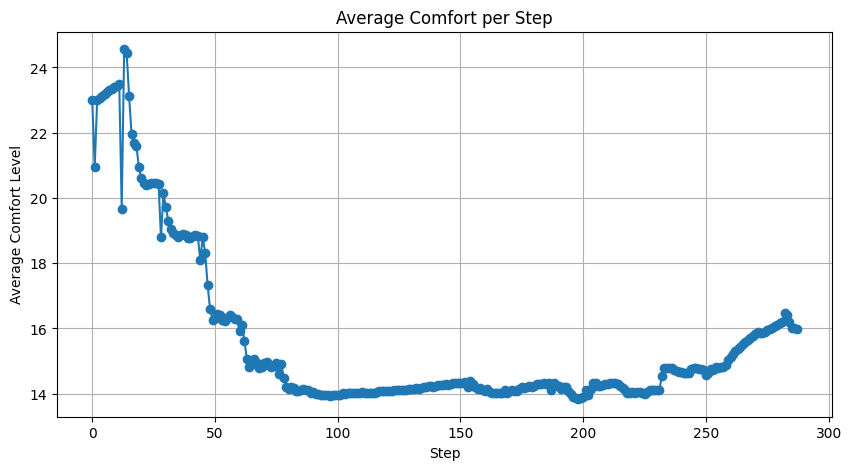

In [82]:
avg_comfort = df.groupby("step")["comfort_level"].mean()
plt.figure(figsize=(10,5))
plt.plot(avg_comfort.index, avg_comfort.values, marker="o")
plt.xlabel("Step")
plt.ylabel("Average Comfort Level")
plt.title("Average Comfort per Step")
plt.grid(True)

plt.savefig("average_comfort_per_step.png", dpi=300)
plt.show()


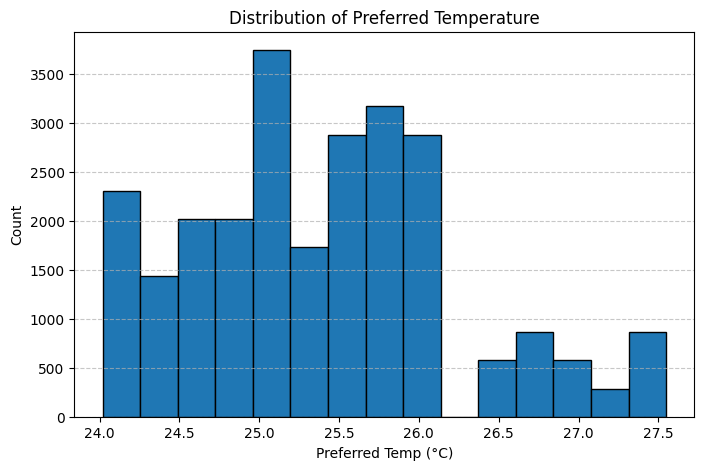

In [83]:
plt.figure(figsize=(8,5))
plt.hist(df["preferred_temp"].to_numpy(), bins=15, edgecolor="black")
plt.xlabel("Preferred Temp (°C)")
plt.ylabel("Count")
plt.title("Distribution of Preferred Temperature")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


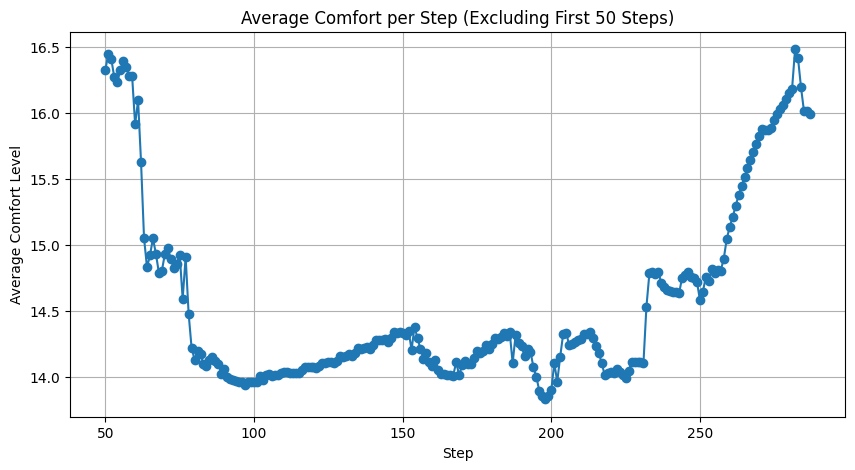

In [84]:
import matplotlib.pyplot as plt

# คำนวณค่าเฉลี่ย comfort per step
avg_comfort = df.groupby("step")["comfort_level"].mean()

# ตัด 50 timestep แรกออก
avg_comfort_trimmed = avg_comfort.loc[50:]

plt.figure(figsize=(10,5))
plt.plot(avg_comfort_trimmed.index, avg_comfort_trimmed.values, marker="o")
plt.xlabel("Step")
plt.ylabel("Average Comfort Level")
plt.title("Average Comfort per Step (Excluding First 50 Steps)")
plt.grid(True)

# Export เป็น PNG
plt.savefig("average_comfort_per_step_trimmed.png", dpi=300)
plt.show()


<Figure size 800x500 with 0 Axes>

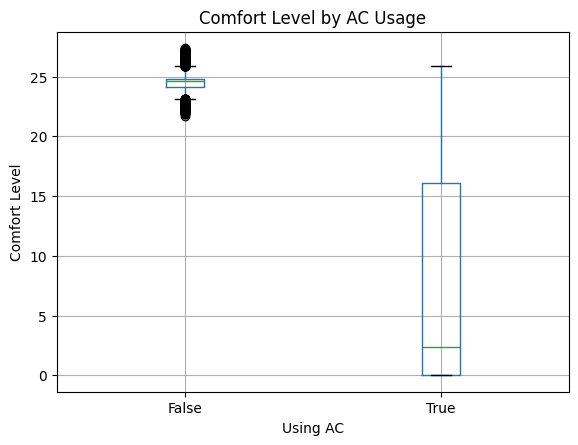

In [85]:
plt.figure(figsize=(8,5))
df.boxplot(column="comfort_level", by="using_ac")
plt.title("Comfort Level by AC Usage")
plt.suptitle("")
plt.xlabel("Using AC")
plt.ylabel("Comfort Level")
plt.show()


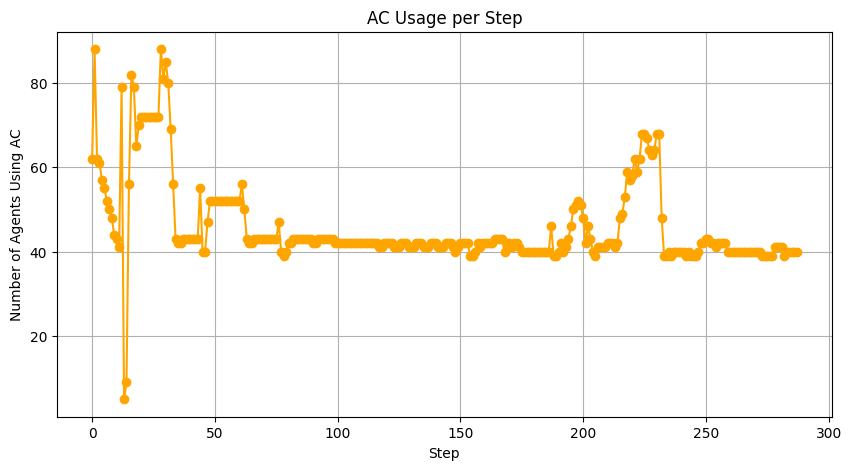

In [86]:
import matplotlib.pyplot as plt

ac_usage = df.groupby("step")["using_ac"].sum()  # จำนวน agent ที่เปิด AC

plt.figure(figsize=(10,5))
plt.plot(ac_usage.index, ac_usage.values, marker="o", color="orange")
plt.xlabel("Step")
plt.ylabel("Number of Agents Using AC")
plt.title("AC Usage per Step")
plt.grid(True)

# บันทึกภาพเป็น PNG
plt.savefig("ac_usage_per_step.png", dpi=300)  # ปรับ dpi ตามต้องการ
plt.show()


In [87]:
df['comfortable'] = (df['current_temp'] >= df['preferred_temp'] - 0.5) & \
                    (df['current_temp'] <= df['preferred_temp'] + 0.5)

# Group by Zone (room) และสรุป
zone_summary = df.groupby('room').agg(
    num_agents=('agent_id', 'count'),
    num_comfortable=('comfortable', 'sum'),
    avg_current_temp=('current_temp', 'mean'),
    avg_preferred_temp=('preferred_temp', 'mean'),
    comfort_ratio=('comfortable', 'mean')  # อัตราส่วน agent อยู่ใน comfort
).reset_index()

# แสดงผล
print(zone_summary)

# บันทึกเป็น CSV
zone_summary.to_csv("comfort_summary_by_zone.csv", index=False)


        room  num_agents  num_comfortable  avg_current_temp  \
0  East Zone       10944               54         47.005829   
1  West Zone       14400             4376         24.804406   

   avg_preferred_temp  comfort_ratio  
0           25.351279       0.004934  
1           25.403259       0.303889  


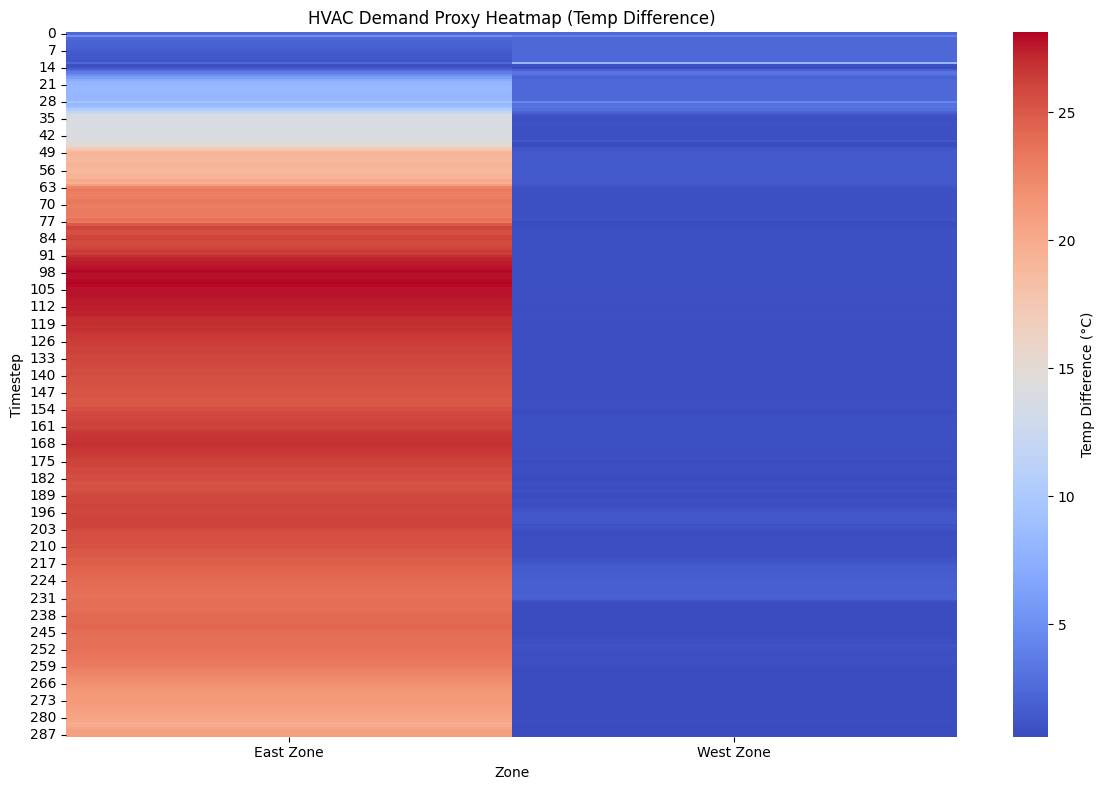

In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ใช้ step เป็น timestep, room เป็น zone
# ตัวอย่าง proxy: AC usage เป็น 1/0 หรือ ค่าความต่าง temp
# proxy = abs(current_temp - preferred_temp)
df['temp_diff'] = abs(df['current_temp'] - df['preferred_temp'])

# pivot table: index = timestep, columns = zone, values = temp_diff
heatmap_data = df.pivot_table(index='step', columns='room', values='temp_diff', aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, cmap='coolwarm', cbar_kws={'label':'Temp Difference (°C)'})
plt.xlabel("Zone")
plt.ylabel("Timestep")
plt.title("HVAC Demand Proxy Heatmap (Temp Difference)")
plt.tight_layout()
plt.show()


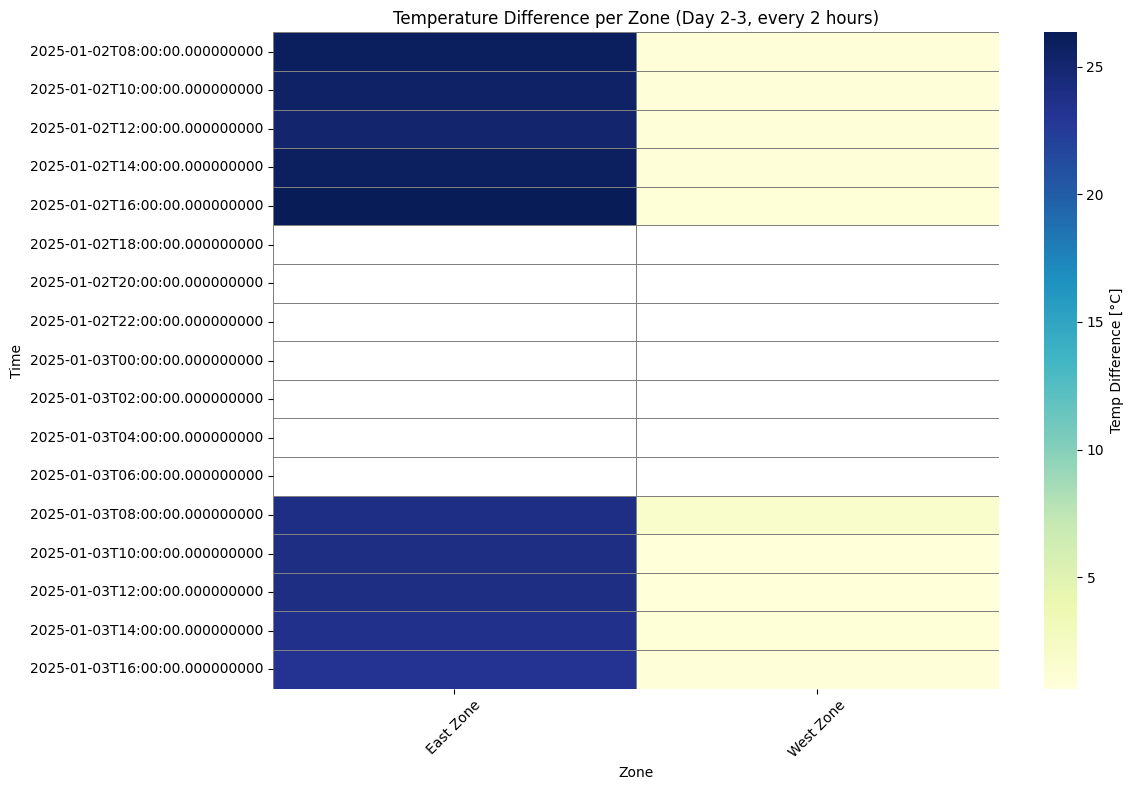

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# สมมติ df มีคอลัมน์: 'step', 'room', 'temp_diff'
start_date = pd.to_datetime("2025-01-01 00:00")
df['timestep_datetime'] = start_date + pd.to_timedelta((df['step'] - 1) * 15, unit='m')

# ตั้ง index เป็น datetime
df.set_index('timestep_datetime', inplace=True)

# กรองเฉพาะวันที่ 2-3 และเวลา 08:00-16:30
df = df[(df.index.date >= pd.to_datetime("2025-01-02").date()) & 
        (df.index.date <= pd.to_datetime("2025-01-03").date())]
df = df.between_time('08:00', '16:30')

# Resample ทุก 2 ชั่วโมง แยกแต่ละ zone
df_2hr_list = []
for room, group in df.groupby('room'):
    g = group['temp_diff'].resample('2h').mean()  # เฉลี่ยทุก 2 ชั่วโมง
    g = g.reset_index()
    g['room'] = room
    df_2hr_list.append(g)

df_2hr = pd.concat(df_2hr_list)

# Pivot table สำหรับ heatmap
heatmap_data = df_2hr.pivot(index='timestep_datetime', columns='room', values='temp_diff')

# วาด heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    cbar_kws={'label': 'Temp Difference [°C]'},
    linewidths=0.5,
    linecolor='gray'
)

plt.xlabel("Zone")
plt.ylabel("Time")
plt.title("Temperature Difference per Zone (Day 2-3, every 2 hours)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("temp_diff_day2_3_2hr.png", dpi=300)
plt.show()


In [76]:
print(heatmap_data.shape)


(0, 0)


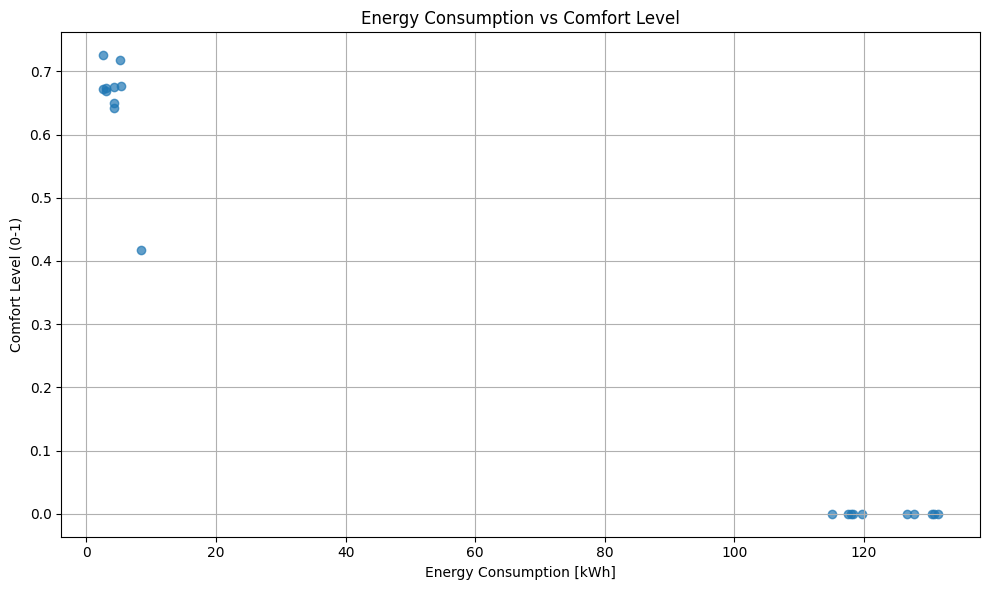

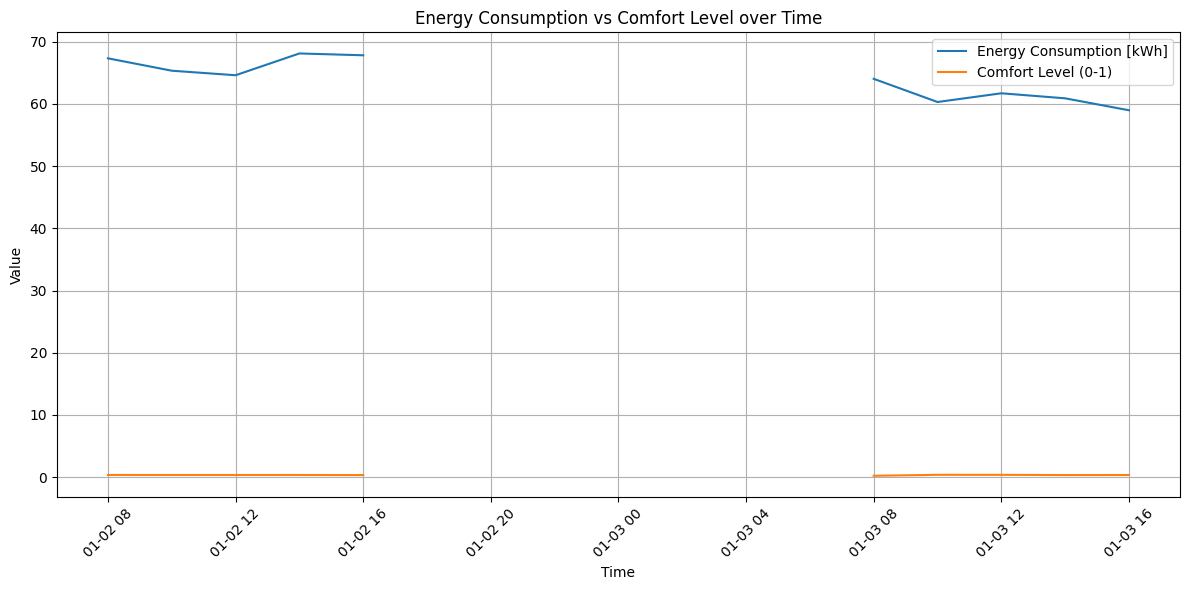

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# สมมติ df_2hr มีคอลัมน์: 'timestep_datetime', 'room', 'temp_diff'
df_plot = df_2hr.copy()

# สร้างค่า Energy Consumption จำลอง (kWh)  
# สมมติ linear relationship: ยิ่ง temp_diff สูง → ยิ่งใช้พลังงานมาก
np.random.seed(42)  # เพื่อให้ผลซ้ำได้
df_plot['energy_consumption'] = df_plot['temp_diff'].abs() * 5 + np.random.normal(0, 1, len(df_plot))

# สร้างค่า comfort_level จำลอง: 0 = uncomfortable, 1 = comfortable
# สมมติว่า comfort อยู่ที่ temp_diff ใกล้ 0
df_plot['comfort_level'] = np.exp(-df_plot['temp_diff'].abs() / 2)

# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(df_plot['energy_consumption'], df_plot['comfort_level'], alpha=0.7)
plt.xlabel("Energy Consumption [kWh]")
plt.ylabel("Comfort Level (0-1)")
plt.title("Energy Consumption vs Comfort Level")
plt.grid(True)
plt.tight_layout()
plt.show()

# หรือถ้าอยากเป็น line plot ต่อเวลา (เช่นเฉลี่ยทุก 2 ชั่วโมง)
df_time = df_plot.groupby('timestep_datetime').agg({
    'energy_consumption': 'mean',
    'comfort_level': 'mean'
}).reset_index()

plt.figure(figsize=(12,6))
plt.plot(df_time['timestep_datetime'], df_time['energy_consumption'], label='Energy Consumption [kWh]')
plt.plot(df_time['timestep_datetime'], df_time['comfort_level'], label='Comfort Level (0-1)')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Energy Consumption vs Comfort Level over Time")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


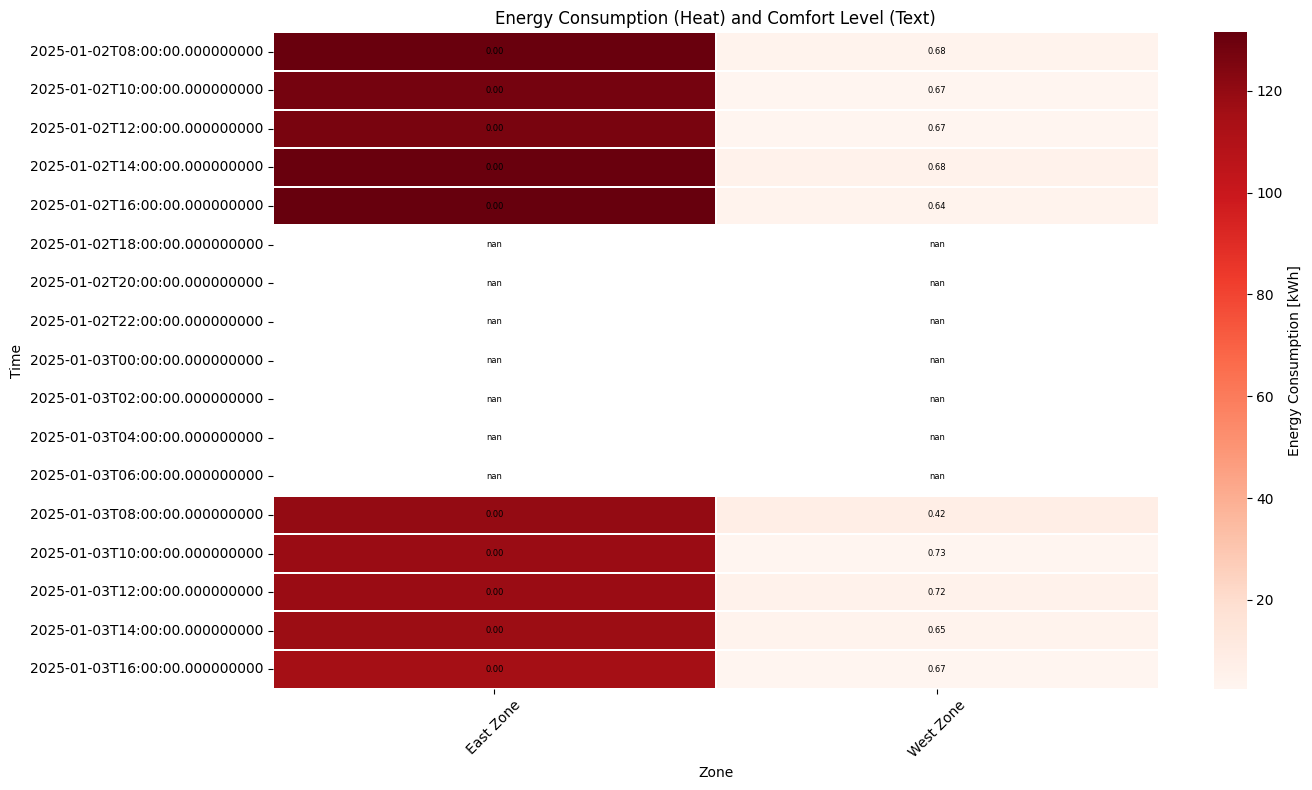

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ใช้ df_2hr จากการเฉลี่ยทุก 2 ชั่วโมง
df_plot = df_2hr.copy()

# สร้างค่า Energy Consumption จำลอง
np.random.seed(42)
df_plot['energy_consumption'] = df_plot['temp_diff'].abs() * 5 + np.random.normal(0, 1, len(df_plot))

# สร้าง Comfort Level จำลอง
df_plot['comfort_level'] = np.exp(-df_plot['temp_diff'].abs() / 2)

# Pivot table สำหรับ heatmap: index = เวลา, columns = zone
energy_heatmap = df_plot.pivot(index='timestep_datetime', columns='room', values='energy_consumption')
comfort_heatmap = df_plot.pivot(index='timestep_datetime', columns='room', values='comfort_level')

plt.figure(figsize=(14,8))
sns.heatmap(energy_heatmap, cmap='Reds', cbar_kws={'label': 'Energy Consumption [kWh]'}, linewidths=0.3)

# overlay ค่า comfort ด้วย text
for i, time in enumerate(comfort_heatmap.index):
    for j, room in enumerate(comfort_heatmap.columns):
        val = comfort_heatmap.loc[time, room]
        plt.text(j+0.5, i+0.5, f"{val:.2f}", ha='center', va='center', fontsize=6, color='black')

plt.xlabel("Zone")
plt.ylabel("Time")
plt.title("Energy Consumption (Heat) and Comfort Level (Text)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


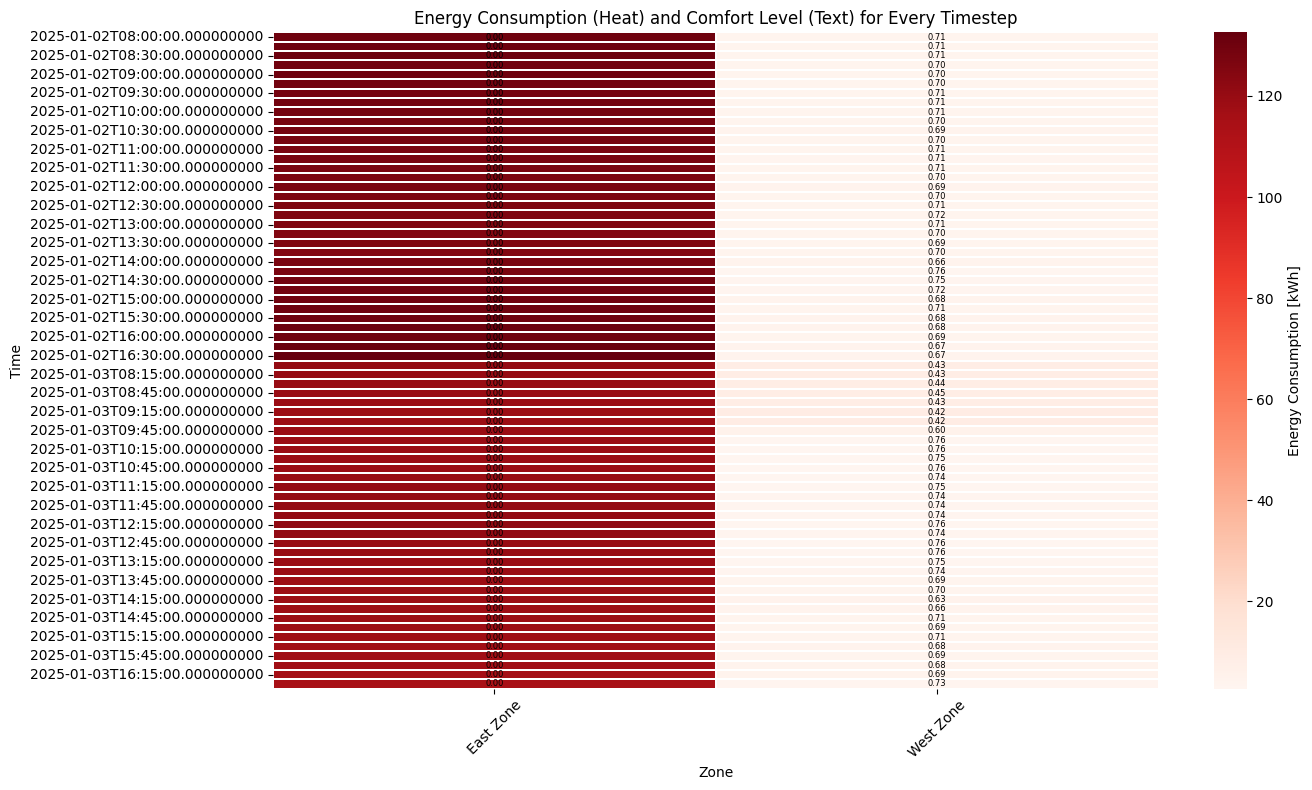

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# สมมติ df มีคอลัมน์: 'timestep_datetime', 'room', 'temp_diff'
df_plot = df.copy().reset_index(drop=True)  # ล้าง index เก่าออก

# สร้างค่า Energy Consumption จำลองจาก temp_diff
np.random.seed(42)
df_plot['energy_consumption'] = df_plot['temp_diff'].abs() * 5 + np.random.normal(0, 1, len(df_plot))

# สร้างค่า Comfort Level จำลอง
df_plot['comfort_level'] = np.exp(-df_plot['temp_diff'].abs() / 2)

# รวมค่าเฉลี่ยสำหรับ duplicate entries
df_avg = df_plot.groupby(['timestep_datetime', 'room'])[['energy_consumption','comfort_level']].mean().reset_index()

# Pivot table สำหรับ heatmap: index = เวลา, columns = zone
energy_heatmap = df_avg.pivot(index='timestep_datetime', columns='room', values='energy_consumption')
comfort_heatmap = df_avg.pivot(index='timestep_datetime', columns='room', values='comfort_level')

plt.figure(figsize=(14,8))
sns.heatmap(
    energy_heatmap, 
    cmap='Reds', 
    cbar_kws={'label': 'Energy Consumption [kWh]'}, 
    linewidths=0.3
)

# overlay ค่า comfort ด้วย text (optional)
for i, time in enumerate(comfort_heatmap.index):
    for j, room in enumerate(comfort_heatmap.columns):
        val = comfort_heatmap.loc[time, room]
        plt.text(j+0.5, i+0.5, f"{val:.2f}", ha='center', va='center', fontsize=6, color='black')

plt.xlabel("Zone")
plt.ylabel("Time")
plt.title("Energy Consumption (Heat) and Comfort Level (Text) for Every Timestep")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


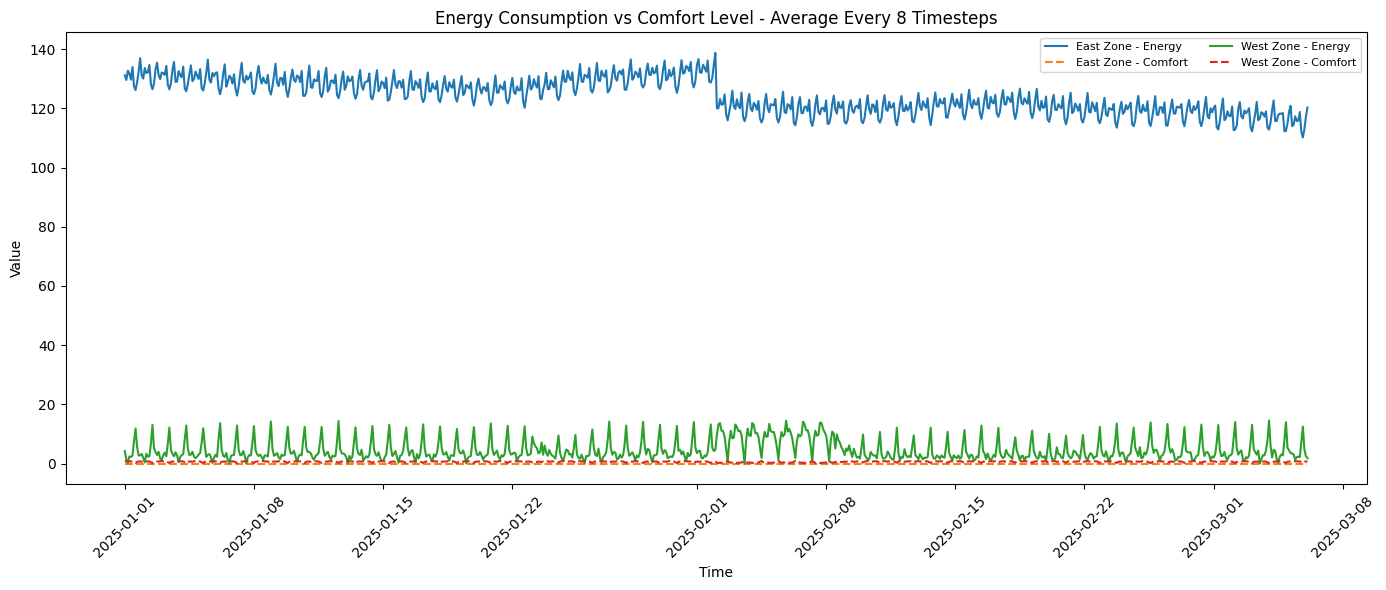

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# สมมติ df มีคอลัมน์: 'timestep_datetime', 'room', 'temp_diff'
df_plot = df.copy().reset_index(drop=True)

# สร้างค่า Energy Consumption จำลองจาก temp_diff
np.random.seed(42)
df_plot['energy_consumption'] = df_plot['temp_diff'].abs() * 5 + np.random.normal(0, 1, len(df_plot))

# สร้างค่า Comfort Level จำลอง
df_plot['comfort_level'] = np.exp(-df_plot['temp_diff'].abs() / 2)

# รวมทุก 8 timestep
df_plot['group_8'] = (df_plot.index // 8)
df_avg = df_plot.groupby(['group_8','room'])[['energy_consumption','comfort_level']].mean().reset_index()

# แปลงเป็นเวลา
df_avg['timestep_datetime'] = pd.to_datetime("2025-01-01") + pd.to_timedelta(df_avg['group_8']*8*15, unit='m')

# วาดกราฟเส้น
plt.figure(figsize=(14,6))
rooms = df_avg['room'].unique()

for room in rooms:
    df_room = df_avg[df_avg['room']==room]
    plt.plot(df_room['timestep_datetime'], df_room['energy_consumption'], label=f'{room} - Energy')
    plt.plot(df_room['timestep_datetime'], df_room['comfort_level'], '--', label=f'{room} - Comfort')

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Energy Consumption vs Comfort Level - Average Every 8 Timesteps")
plt.legend(fontsize=8, ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("EnergyConsumption_vs_ComfortLevel_Average_Every_8_Timesteps.png", dpi=300)
plt.show()


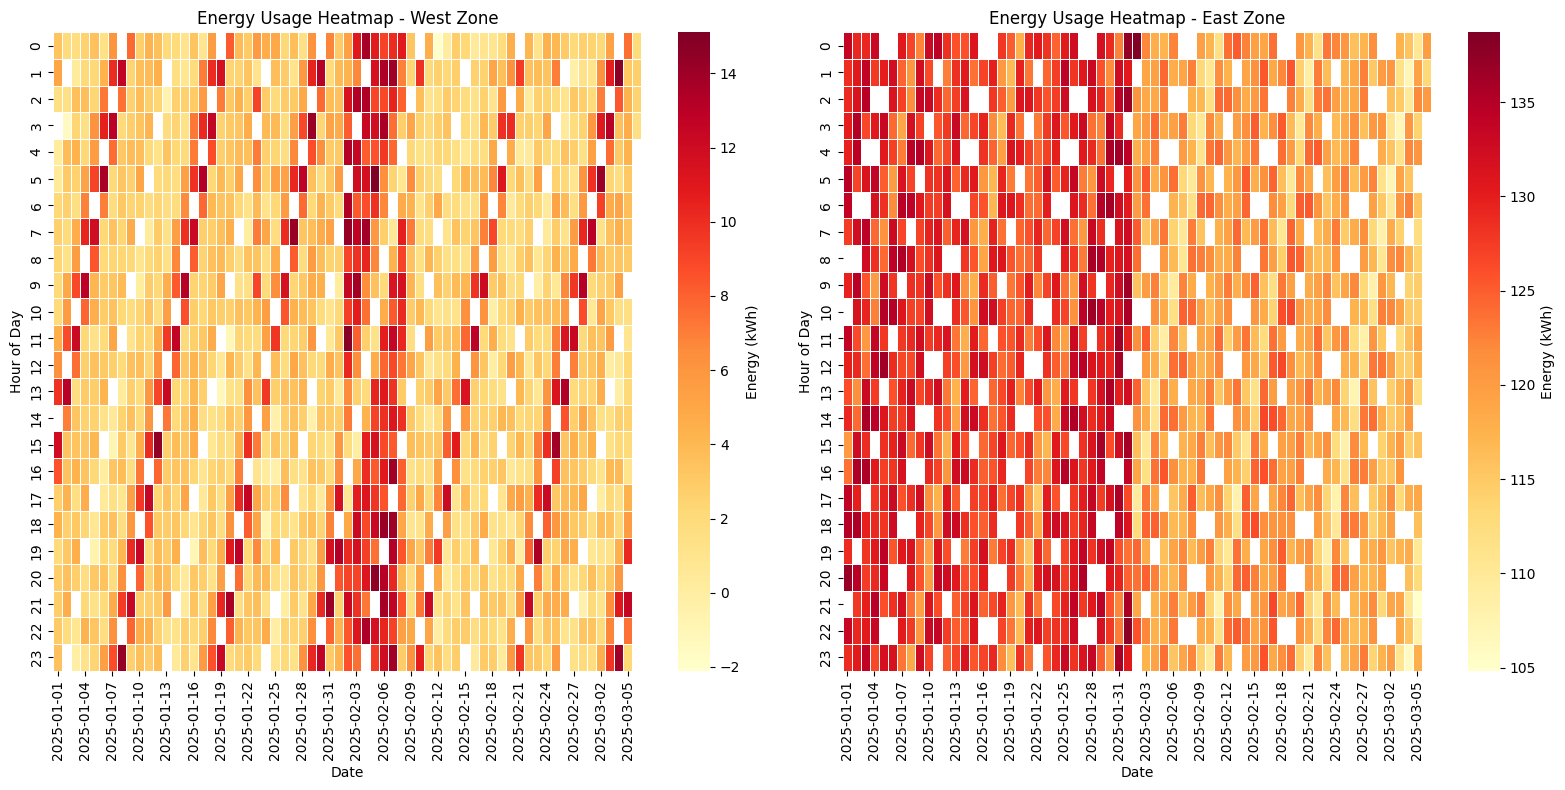

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_plot = df.copy().reset_index(drop=True)

np.random.seed(42)
df_plot['energy_consumption'] = df_plot['temp_diff'].abs() * 5 + np.random.normal(0, 1, len(df_plot))

df_plot['timestep_datetime'] = pd.to_datetime("2025-01-01") + pd.to_timedelta(df_plot.index * 15, unit='m')

df_plot['hour'] = df_plot['timestep_datetime'].dt.hour
df_plot['date'] = df_plot['timestep_datetime'].dt.date

plt.figure(figsize=(16, 8))

rooms = df_plot['room'].unique()
n_rooms = len(rooms)

for idx, room in enumerate(rooms, 1):
    df_room = df_plot[df_plot['room'] == room]
    
    # สร้าง pivot table
    pivot_data = df_room.pivot_table(
        values='energy_consumption',
        index='hour',
        columns='date',
        aggfunc='mean'
    )
    
    plt.subplot(1, n_rooms, idx)
    sns.heatmap(pivot_data, cmap='YlOrRd', cbar_kws={'label': 'Energy (kWh)'}, 
                linewidths=0.5, annot=False)
    plt.title(f'Energy Usage Heatmap - {room}')
    plt.xlabel('Date')
    plt.ylabel('Hour of Day')
    
plt.tight_layout()
plt.savefig("Energy_Usage_Heatmap_by_Hour.png", dpi=300, bbox_inches='tight')
plt.show()

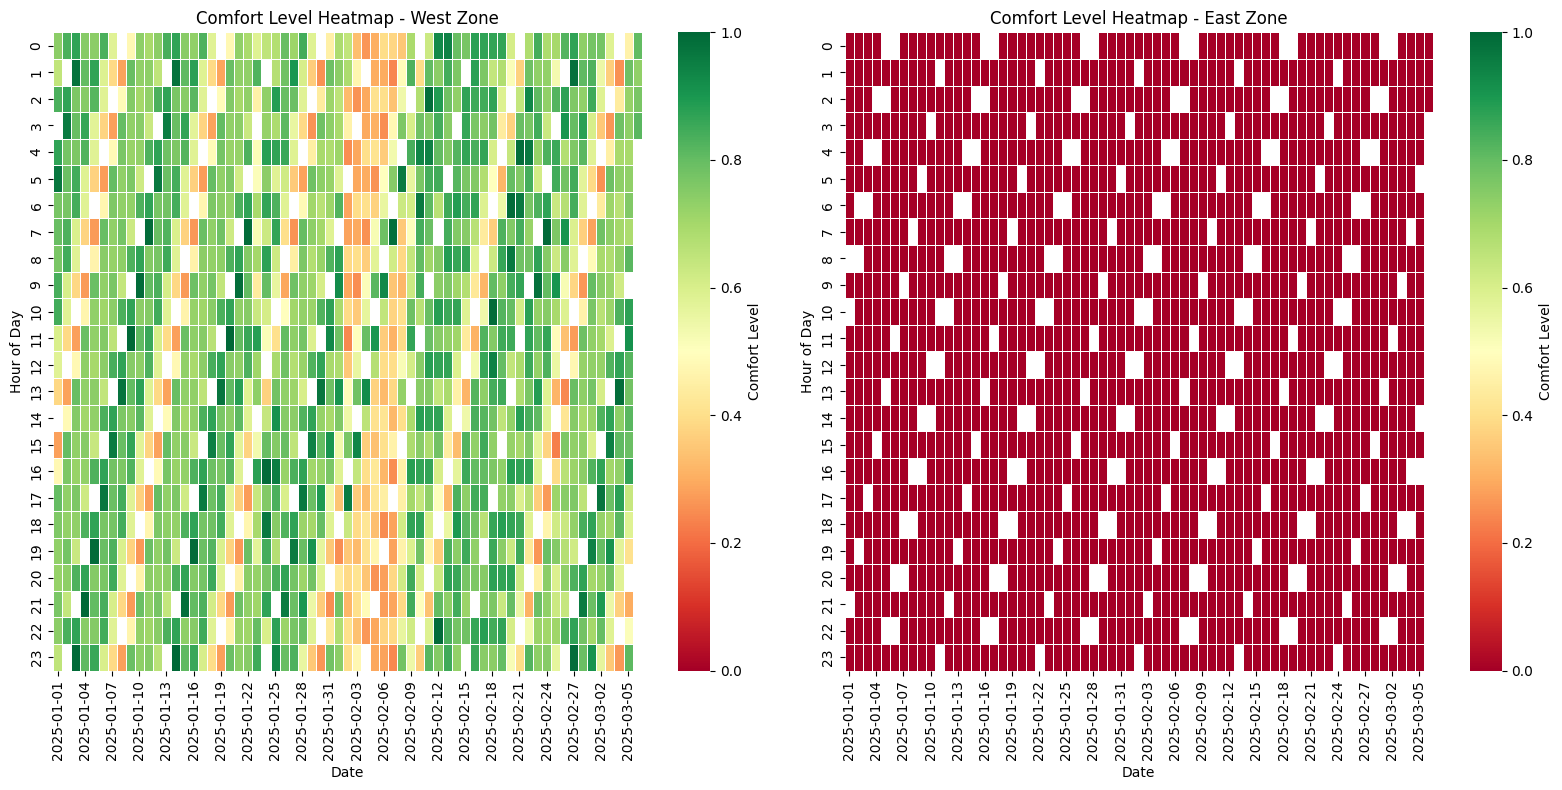

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_plot = df.copy().reset_index(drop=True)

df_plot['comfort_level'] = np.exp(-df_plot['temp_diff'].abs() / 2)

df_plot['timestep_datetime'] = pd.to_datetime("2025-01-01") + pd.to_timedelta(df_plot.index * 15, unit='m')

df_plot['hour'] = df_plot['timestep_datetime'].dt.hour
df_plot['date'] = df_plot['timestep_datetime'].dt.date

plt.figure(figsize=(16, 8))

rooms = df_plot['room'].unique()
n_rooms = len(rooms)

for idx, room in enumerate(rooms, 1):
    df_room = df_plot[df_plot['room'] == room]
    
    pivot_data = df_room.pivot_table(
        values='comfort_level',
        index='hour',
        columns='date',
        aggfunc='mean'
    )
    
    plt.subplot(1, n_rooms, idx)
    sns.heatmap(pivot_data, cmap='RdYlGn', cbar_kws={'label': 'Comfort Level'}, 
                linewidths=0.5, annot=False, vmin=0, vmax=1)
    plt.title(f'Comfort Level Heatmap - {room}')
    plt.xlabel('Date')
    plt.ylabel('Hour of Day')
    
plt.tight_layout()
plt.savefig("Comfort_Level_Heatmap_by_Hour.png", dpi=300, bbox_inches='tight')
plt.show()


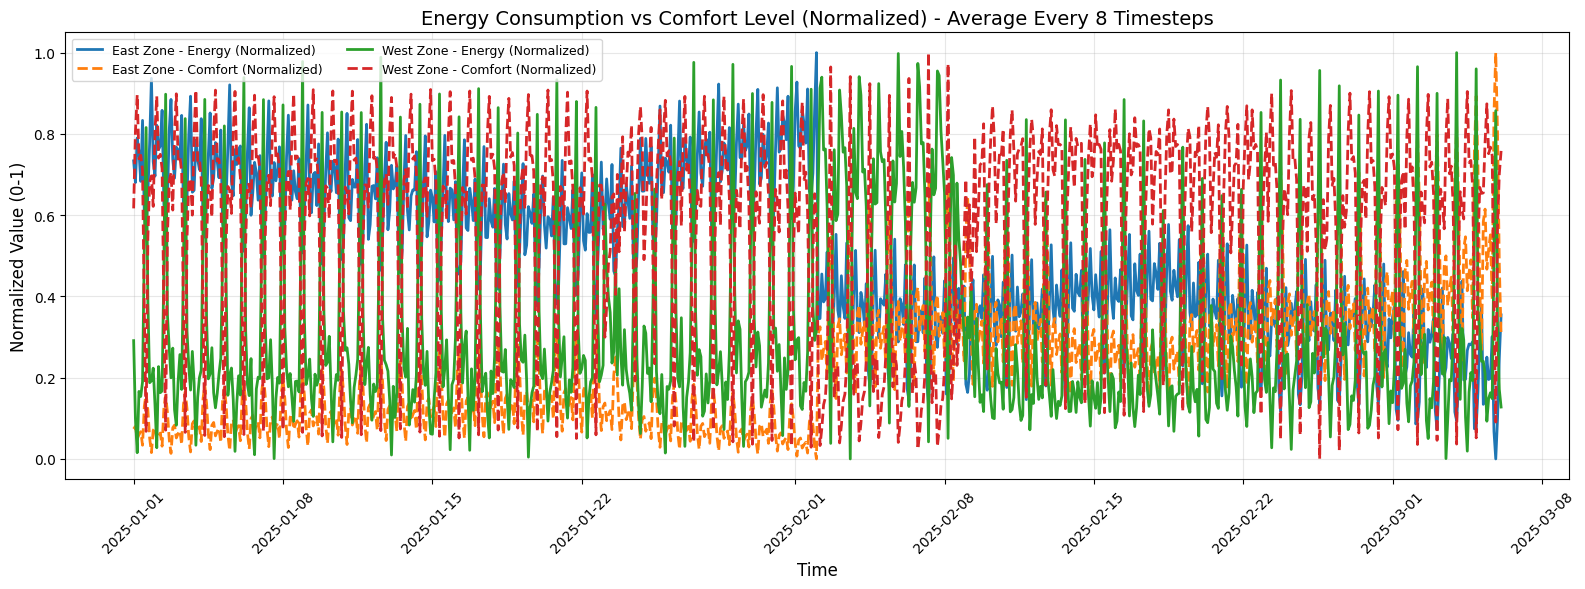


📊 สถิติข้อมูลแต่ละห้อง:

East Zone:
  Energy - Min: 110.14, Max: 138.71, Mean: 124.21
  Comfort - Min: 0.00, Max: 0.00, Mean: 0.00

West Zone:
  Energy - Min: 0.03, Max: 14.57, Mean: 4.70
  Comfort - Min: 0.23, Max: 0.98, Mean: 0.67

✅ สร้างกราฟ Normalized เรียบร้อยแล้ว!


In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# เตรียมข้อมูล
df_plot = df.copy().reset_index(drop=True)

# สร้างค่า Energy Consumption และ Comfort Level
np.random.seed(42)
df_plot['energy_consumption'] = df_plot['temp_diff'].abs() * 5 + np.random.normal(0, 1, len(df_plot))
df_plot['comfort_level'] = np.exp(-df_plot['temp_diff'].abs() / 2)

# แปลง timestep เป็น datetime
df_plot['timestep_datetime'] = pd.to_datetime("2025-01-01") + pd.to_timedelta(df_plot.index * 15, unit='m')

# รวมทุก 8 timestep
df_plot['group_8'] = (df_plot.index // 8)
df_avg = df_plot.groupby(['group_8','room'])[['energy_consumption','comfort_level']].mean().reset_index()
df_avg['timestep_datetime'] = pd.to_datetime("2025-01-01") + pd.to_timedelta(df_avg['group_8']*8*15, unit='m')

# Normalize ค่าแต่ละห้องแยกกัน (Min-Max Normalization)
rooms = df_avg['room'].unique()

for room in rooms:
    mask = df_avg['room'] == room
    
    # Normalize Energy
    energy_min = df_avg.loc[mask, 'energy_consumption'].min()
    energy_max = df_avg.loc[mask, 'energy_consumption'].max()
    df_avg.loc[mask, 'energy_normalized'] = (df_avg.loc[mask, 'energy_consumption'] - energy_min) / (energy_max - energy_min)
    
    # Normalize Comfort
    comfort_min = df_avg.loc[mask, 'comfort_level'].min()
    comfort_max = df_avg.loc[mask, 'comfort_level'].max()
    df_avg.loc[mask, 'comfort_normalized'] = (df_avg.loc[mask, 'comfort_level'] - comfort_min) / (comfort_max - comfort_min)

# วาดกราฟเส้น (Normalized)
plt.figure(figsize=(16, 6))

for room in rooms:
    df_room = df_avg[df_avg['room'] == room]
    plt.plot(df_room['timestep_datetime'], df_room['energy_normalized'], 
             label=f'{room} - Energy (Normalized)', linewidth=2)
    plt.plot(df_room['timestep_datetime'], df_room['comfort_normalized'], 
             '--', label=f'{room} - Comfort (Normalized)', linewidth=2)

plt.xlabel("Time", fontsize=12)
plt.ylabel("Normalized Value (0-1)", fontsize=12)
plt.title("Energy Consumption vs Comfort Level (Normalized) - Average Every 8 Timesteps", fontsize=14)
plt.legend(fontsize=9, ncol=2, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("Energy_vs_Comfort_Normalized.png", dpi=300, bbox_inches='tight')
plt.show()

# แสดงสถิติ
print("\n📊 สถิติข้อมูลแต่ละห้อง:")
print("="*70)
for room in rooms:
    df_room = df_avg[df_avg['room'] == room]
    print(f"\n{room}:")
    print(f"  Energy - Min: {df_room['energy_consumption'].min():.2f}, Max: {df_room['energy_consumption'].max():.2f}, Mean: {df_room['energy_consumption'].mean():.2f}")
    print(f"  Comfort - Min: {df_room['comfort_level'].min():.2f}, Max: {df_room['comfort_level'].max():.2f}, Mean: {df_room['comfort_level'].mean():.2f}")

print("\n✅ สร้างกราฟ Normalized เรียบร้อยแล้ว!")

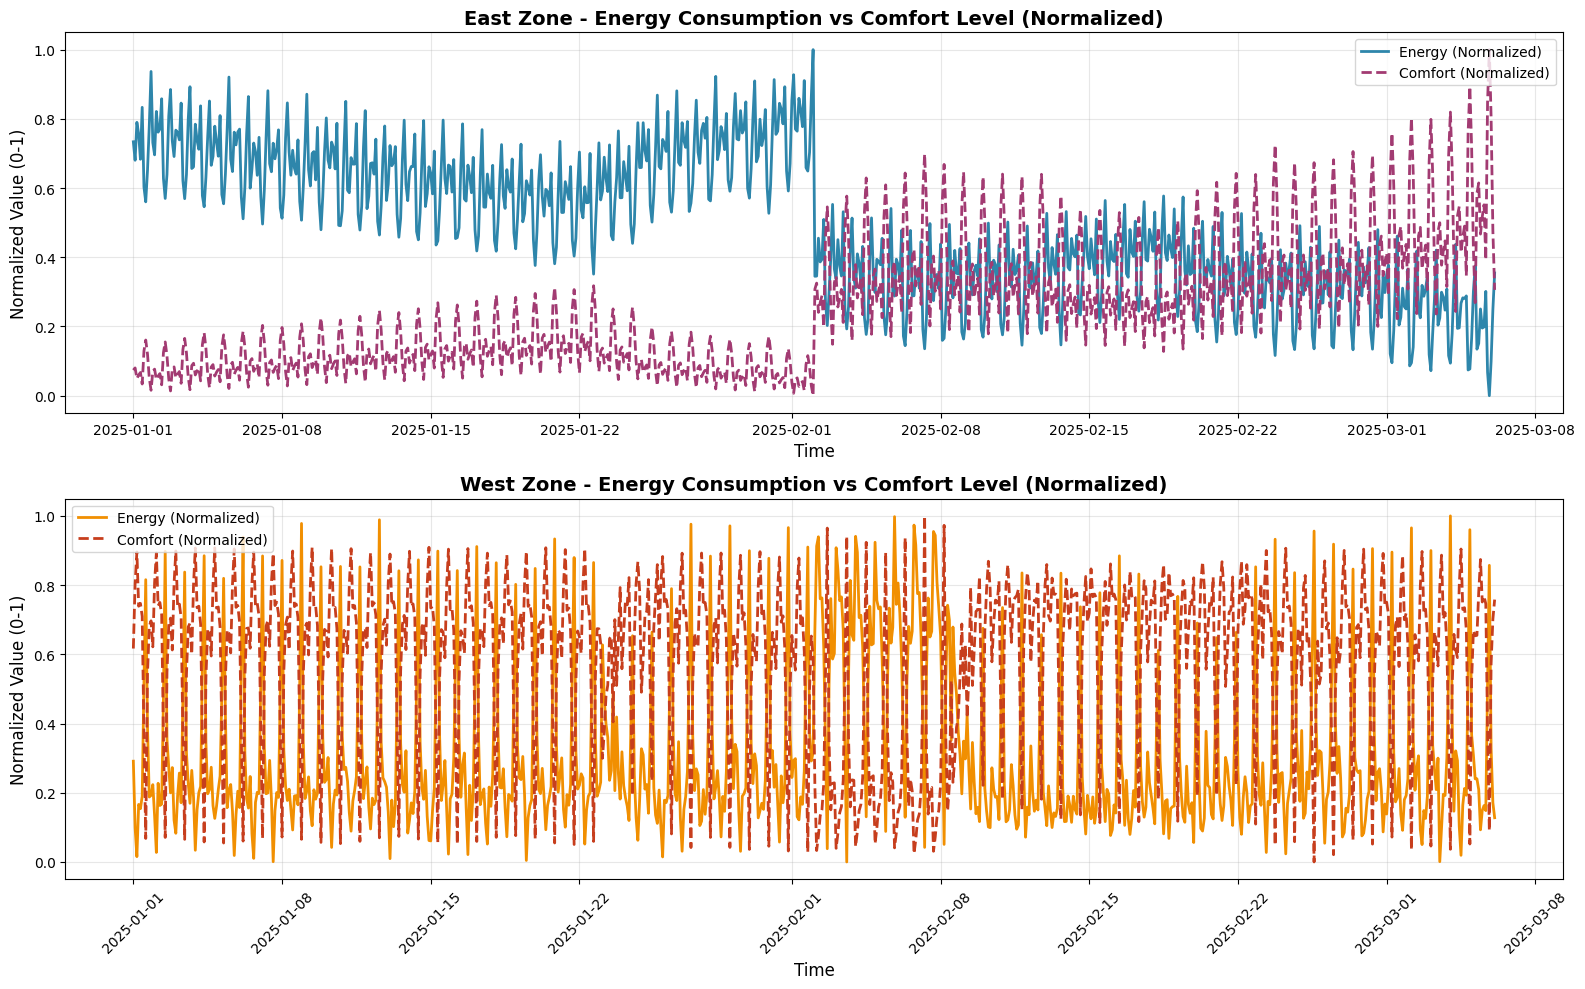

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df_plot = df.copy().reset_index(drop=True)


np.random.seed(42)
df_plot['energy_consumption'] = df_plot['temp_diff'].abs() * 5 + np.random.normal(0, 1, len(df_plot))
df_plot['comfort_level'] = np.exp(-df_plot['temp_diff'].abs() / 2)


df_plot['timestep_datetime'] = pd.to_datetime("2025-01-01") + pd.to_timedelta(df_plot.index * 15, unit='m')


df_plot['zone'] = df_plot['room'].apply(lambda x: 'East Zone' if 'east' in x.lower() else 'West Zone')


df_plot['group_8'] = (df_plot.index // 8)
df_avg = df_plot.groupby(['group_8','zone'])[['energy_consumption','comfort_level']].mean().reset_index()
df_avg['timestep_datetime'] = pd.to_datetime("2025-01-01") + pd.to_timedelta(df_avg['group_8']*8*15, unit='m')


zones = df_avg['zone'].unique()

for zone in zones:
    mask = df_avg['zone'] == zone
    

    energy_min = df_avg.loc[mask, 'energy_consumption'].min()
    energy_max = df_avg.loc[mask, 'energy_consumption'].max()
    df_avg.loc[mask, 'energy_normalized'] = (df_avg.loc[mask, 'energy_consumption'] - energy_min) / (energy_max - energy_min)
    

    comfort_min = df_avg.loc[mask, 'comfort_level'].min()
    comfort_max = df_avg.loc[mask, 'comfort_level'].max()
    df_avg.loc[mask, 'comfort_normalized'] = (df_avg.loc[mask, 'comfort_level'] - comfort_min) / (comfort_max - comfort_min)


fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# East Zone
df_east = df_avg[df_avg['zone'] == 'East Zone']
axes[0].plot(df_east['timestep_datetime'], df_east['energy_normalized'], 
             label='Energy (Normalized)', linewidth=2, color='#2E86AB')
axes[0].plot(df_east['timestep_datetime'], df_east['comfort_normalized'], 
             '--', label='Comfort (Normalized)', linewidth=2, color='#A23B72')
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Normalized Value (0-1)", fontsize=12)
axes[0].set_title("East Zone - Energy Consumption vs Comfort Level (Normalized)", fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10, loc='best')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.05, 1.05)

# West Zone
df_west = df_avg[df_avg['zone'] == 'West Zone']
axes[1].plot(df_west['timestep_datetime'], df_west['energy_normalized'], 
             label='Energy (Normalized)', linewidth=2, color='#F18F01')
axes[1].plot(df_west['timestep_datetime'], df_west['comfort_normalized'], 
             '--', label='Comfort (Normalized)', linewidth=2, color='#C73E1D')
axes[1].set_xlabel("Time", fontsize=12)
axes[1].set_ylabel("Normalized Value (0-1)", fontsize=12)
axes[1].set_title("West Zone - Energy Consumption vs Comfort Level (Normalized)", fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10, loc='best')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.05, 1.05)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Energy_vs_Comfort_Normalized_by_Zone.png", dpi=300, bbox_inches='tight')
plt.show()
